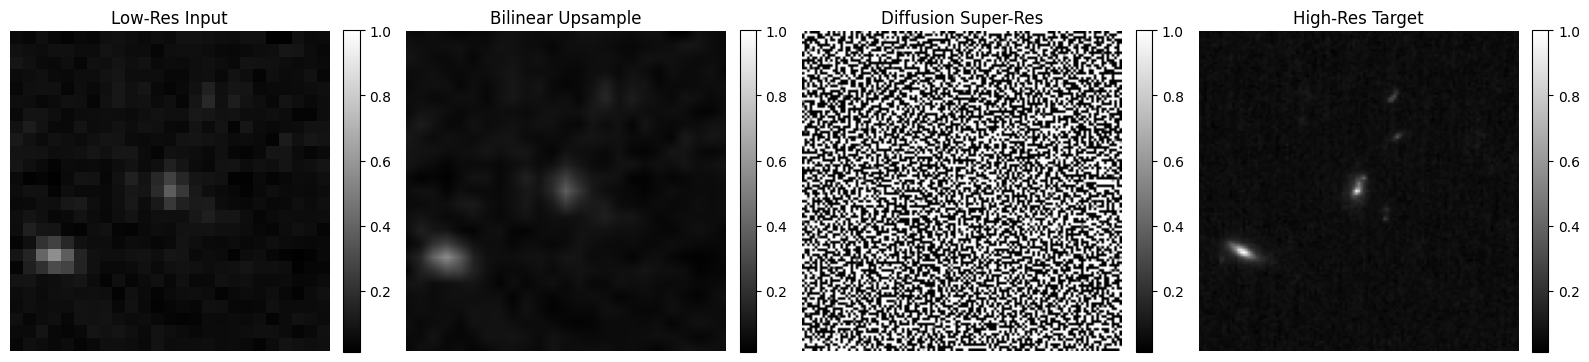

In [36]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

from model import SuperResolutionDiffusion, SuperResDiffusionUNet, Upsampler
from dataset import SuperResolutionDataset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild model exactly as in train.py
unet = SuperResDiffusionUNet(
    in_channels=1,
    out_channels=1,
    hidden_dim=64,
    activation_fn=torch.nn.ReLU,
).to(device)

upsampler = Upsampler(
    in_channels=1,
    out_channels=1,
    upscale_factor=5,
).to(device)

model = SuperResolutionDiffusion(
    unet_model=unet,
    upsampler=upsampler,
    timesteps=500,
    output_size=[125, 125],
    inference_timesteps=50,
).to(device)

state = torch.load("checkpoints/model_epoch_23.pth", map_location=device)
model.load_state_dict(state)
model.eval()


val_ds = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="test",
    sample_fraction=0.1,
)

idx = 2
lr_img, hr_img = val_ds[idx]
lr_batch = lr_img.unsqueeze(0).to(device)

with torch.no_grad():
    sr_sample = model.sample(lr_batch, num_steps=50)
sr_sample = sr_sample[0].cpu()

# Bilinear baseline
bilinear = F.interpolate(
    lr_batch,
    scale_factor=5,
    mode="bilinear",
    align_corners=True
)[0].cpu()

vmin = min(
    lr_img.min().item(),
    hr_img.min().item(),
    bilinear.min().item(),
)
vmax = max(
    lr_img.max().item(),
    hr_img.max().item(),
    bilinear.max().item(),
)

lr_np = lr_img.squeeze().cpu().numpy()
bilin_np = bilinear.squeeze().cpu().numpy()
sr_np = torch.clamp(sr_sample, vmin, vmax).squeeze().numpy()
hr_np = hr_img.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Low-Res Input", "Bilinear Upsample", "Diffusion Super-Res", "High-Res Target"]
images = [lr_np, bilin_np, sr_np, hr_np]

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [37]:
import torch
import torch.nn.functional as F
from model import SuperResolutionDiffusion, SuperResDiffusionUNet, Upsampler
from dataset import SuperResolutionDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- rebuild + load checkpoint ---
unet = SuperResDiffusionUNet(
    in_channels=1,
    out_channels=1,
    hidden_dim=64,
    activation_fn=torch.nn.ReLU,
).to(device)

upsampler = Upsampler(
    in_channels=1,
    out_channels=1,
    upscale_factor=5,
).to(device)

model = SuperResolutionDiffusion(
    unet_model=unet,
    upsampler=upsampler,
    timesteps=500,
    output_size=[125, 125],
    inference_timesteps=50,
).to(device)

# --- small val loader ---
val_ds = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="test",
    sample_fraction=0.02,
)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=8, shuffle=False)

total_mse = 0.0
total_mse_random = 0.0
n = 0

with torch.no_grad():
    for lr, hr in val_loader:
        lr, hr = lr.to(device), hr.to(device)
        B = lr.shape[0]
        t = torch.randint(0, model.timesteps, (B,), device=device)

        # make x_t, noise using SAME q_sample as training
        hr_resized = F.interpolate(hr, size=(125, 125), mode="bilinear", align_corners=True)
        x_t, true_noise = model.q_sample(hr_resized, t)

        # model prediction
        cond = model.upsampler(lr)
        pred_noise = model.diffusion(x_t, t, cond)
        if pred_noise.shape[2:] != true_noise.shape[2:]:
            pred_noise = F.interpolate(pred_noise, size=true_noise.shape[2:], mode="bilinear", align_corners=True)

        mse = F.mse_loss(pred_noise, true_noise).item()

        # baseline: compare true noise to *another* random noise sample
        random_noise = torch.randn_like(true_noise)
        mse_random = F.mse_loss(random_noise, true_noise).item()

        total_mse += mse * B
        total_mse_random += mse_random * B
        n += B

avg_mse = total_mse / n
avg_mse_random = total_mse_random / n
print("Avg MSE(model vs true noise):   ", avg_mse)
print("Avg MSE(random vs true noise):  ", avg_mse_random)


Avg MSE(model vs true noise):    1.0297850325422466
Avg MSE(random vs true noise):   1.9998391641760773


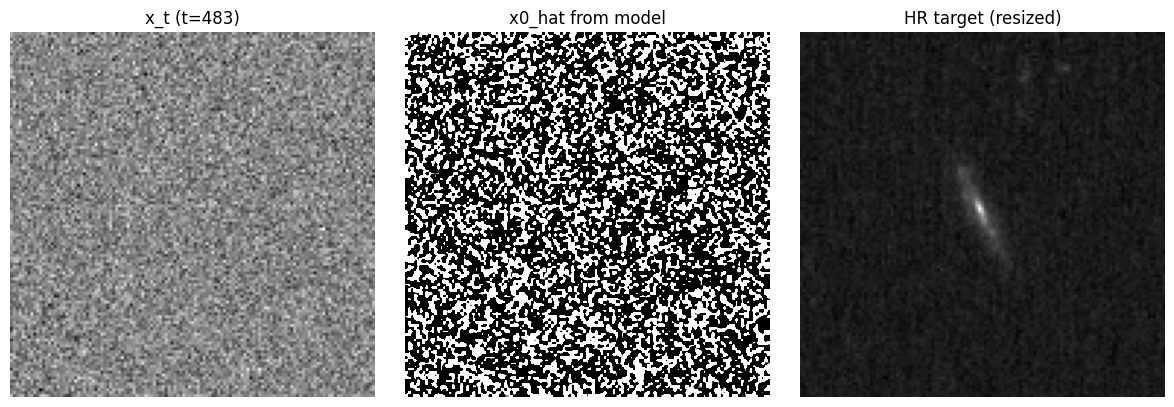

In [38]:
idx = 26
lr_img, hr_img = val_ds[idx]
lr_batch = lr_img.unsqueeze(0).to(device)
hr_batch = hr_img.unsqueeze(0).to(device)

B = 1
t = torch.randint(0, model.timesteps, (B,), device=device)

# Resize HR to model's output size
hr_resized = F.interpolate(
    hr_batch,
    size=(model.output_size[0], model.output_size[1]),
    mode="bilinear",
    align_corners=True
)

# q(x_t | x_0) using SAME diffusion schedule as in the model
noise = torch.randn_like(hr_resized)
sqrt_ab   = model.sqrt_alphas_cumprod[t].view(-1,1,1,1)
sqrt_omab = model.sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1)

x_t = sqrt_ab * hr_resized + sqrt_omab * noise

# conditioning from LR
cond = model.upsampler(lr_batch)

# predict noise with UNet
with torch.no_grad():
    pred_noise = model.diffusion(x_t, t, cond)
    if pred_noise.shape[2:] != x_t.shape[2:]:
        pred_noise = F.interpolate(pred_noise, size=x_t.shape[2:], mode="bilinear", align_corners=True)

# reconstruct x0
x0_hat = (x_t - sqrt_omab * pred_noise) / (sqrt_ab + 1e-8)

# --- visualization ---
x_t_np    = x_t[0].cpu().squeeze().numpy()
x0_np     = x0_hat[0].cpu().squeeze().numpy()
hr_np     = hr_resized[0].cpu().squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x_t_np, cmap="gray")
axes[0].set_title(f"x_t (t={t.item()})")
axes[0].axis("off")

axes[1].imshow(x0_np, cmap="gray", vmin=hr_np.min(), vmax=hr_np.max())
axes[1].set_title("x0_hat from model")
axes[1].axis("off")

axes[2].imshow(hr_np, cmap="gray")
axes[2].set_title("HR target (resized)")
axes[2].axis("off")

plt.tight_layout()
plt.show()
